# Trustworthy ML for Fetal Health Classification from CTG Data

**Complete reproducible pipeline for the paper.**

This notebook implements all six extensions:
1. **Leakage Audit** — comparing pre-split vs. in-CV-fold resampling
2. **Statistical Testing** — 30-seed repeated CV with Friedman + McNemar
3. **Calibration Analysis** — ECE, Brier, reliability diagrams, Platt/isotonic/temperature scaling
4. **Threshold Optimization** — cost-sensitive thresholds, TPR@fixed-FPR, Decision Curve Analysis
5. **Conformal Prediction** — split-conformal for selective classification
6. **SHAP Error Analysis** — feature attribution + UMAP of residual errors

Runtime on Colab (CPU): ~45–75 min end-to-end. Use a T4 GPU runtime if you want faster LightGBM/XGBoost.


## 0. Environment Setup

In [ ]:
# Install dependencies (Colab already has most of these)
!pip install -q lightgbm==4.3.0 xgboost==2.0.3 catboost==1.2.5 \
    imbalanced-learn==0.12.3 scikit-learn==1.5.0 \
    shap==0.45.1 umap-learn==0.5.6 \
    mapie==0.9.1 \
    scikit-posthocs==0.9.0 \
    ucimlrepo

In [2]:
!pip install -q lightgbm xgboost catboost imbalanced-learn scikit-posthocs shap umap-learn statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.9 MB/s eta 0:00:00


In [2]:
!pip install -q --upgrade pip
!pip install -q lightgbm xgboost catboost imbalanced-learn scikit-posthocs shap umap-learn statsmodels

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 32.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [3]:
import os, json, warnings, itertools, pickle
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     GridSearchCV, cross_val_score)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                             precision_score, confusion_matrix,
                             classification_report, brier_score_loss,
                             roc_auc_score, roc_curve)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Models
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              AdaBoostClassifier, GradientBoostingClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Statistics
from scipy.stats import friedmanchisquare, wilcoxon
import scikit_posthocs as sp
from statsmodels.stats.contingency_tables import mcnemar

# Explainability
import shap
import umap

warnings.filterwarnings('ignore')
np.random.seed(42)

# Output directory
OUTDIR = Path('outputs')
OUTDIR.mkdir(exist_ok=True)
(OUTDIR / 'figures').mkdir(exist_ok=True)
(OUTDIR / 'tables').mkdir(exist_ok=True)

print('Setup complete.')

Setup complete.


## 1. Load the CTG Dataset

**Two methods — use whichever works for you.**

In [4]:
!
# ============================================================
# METHOD A: Kaggle CSV (recommended — matches competitor papers)
# ============================================================
# Step 1: Upload your fetal_health.csv to Colab (drag-drop into files panel)
# Step 2: Uncomment the block below

# df = pd.read_csv('fetal_health.csv')
# TARGET_COL = 'fetal_health'  # labels are 1.0, 2.0, 3.0
# df[TARGET_COL] = df[TARGET_COL].astype(int) - 1   # remap to 0, 1, 2
# print(df.shape, df[TARGET_COL].value_counts())

# ============================================================
# METHOD B: UCI direct (no Kaggle account needed)
# ============================================================
!pip install -q ucimlrepo
from ucimlrepo import fetch_ucirepo
ctg = fetch_ucirepo(id=193)
X_raw = ctg.data.features
y_raw = ctg.data.targets['NSP']     # N=1, S=2, P=3 — remap to 0/1/2

# Keep only the 21 features used by Nazli 2025 / Hawrami 2026
# Drop 'CLASS' (the 10-class FHR pattern) — we only model the 3-class NSP target
feature_cols = [c for c in X_raw.columns if c != 'CLASS']
X = X_raw[feature_cols].copy()
y = (y_raw - 1).astype(int).values   # 0=Normal, 1=Suspect, 2=Pathological

df = X.copy()
df['target'] = y
print('Shape:', df.shape)
print('Class distribution:')
print(pd.Series(y).value_counts().sort_index().rename(
    {0: 'Normal', 1: 'Suspect', 2: 'Pathological'}))

Shape: (2126, 22)
Class distribution:
Normal          1655
Suspect          295
Pathological     176
Name: count, dtype: int64


In [5]:
# Save raw arrays for later use
FEATURE_NAMES = list(X.columns)
CLASS_NAMES = ['Normal', 'Suspect', 'Pathological']
N_CLASSES = 3

# Check for missing values
assert X.isna().sum().sum() == 0, 'Unexpected NaNs in features'
print(f'{len(FEATURE_NAMES)} features, {len(y)} samples, {N_CLASSES} classes')

21 features, 2126 samples, 3 classes


## 2. Define the Model Zoo

12 classifiers × 2 imbalance strategies (SMOTE vs. Class Weighting).

In [6]:
def get_models(strategy: str, seed: int = 42):
    """Return dict of untrained models configured for either 'smote' or 'cw'.
    For 'smote' we disable class_weight; the SMOTE step in the pipeline handles imbalance.
    For 'cw' we set class_weight='balanced' (or equivalent).
    """
    if strategy == 'cw':
        cw = 'balanced'
        models = {
            'LGBM':  LGBMClassifier(class_weight=cw, random_state=seed, verbose=-1),
            'XGB':   XGBClassifier(random_state=seed, eval_metric='mlogloss',
                                   use_label_encoder=False),
            'RF':    RandomForestClassifier(class_weight=cw, random_state=seed),
            'CatB':  CatBoostClassifier(auto_class_weights='Balanced',
                                        random_seed=seed, verbose=0),
            'ET':    ExtraTreesClassifier(class_weight=cw, random_state=seed),
            'AdaB':  AdaBoostClassifier(random_state=seed),
            'GB':    GradientBoostingClassifier(random_state=seed),
            'DT':    DecisionTreeClassifier(class_weight=cw, random_state=seed),
            'KNN':   KNeighborsClassifier(),
            'MLP':   MLPClassifier(random_state=seed, max_iter=500),
            'SVC':   SVC(class_weight=cw, probability=True, random_state=seed),
            'LR':    LogisticRegression(class_weight=cw, max_iter=2000, random_state=seed),
            'Ridge': RidgeClassifier(class_weight=cw, random_state=seed),
        }
    else:  # smote
        models = {
            'LGBM':  LGBMClassifier(random_state=seed, verbose=-1),
            'XGB':   XGBClassifier(random_state=seed, eval_metric='mlogloss',
                                   use_label_encoder=False),
            'RF':    RandomForestClassifier(random_state=seed),
            'CatB':  CatBoostClassifier(random_seed=seed, verbose=0),
            'ET':    ExtraTreesClassifier(random_state=seed),
            'AdaB':  AdaBoostClassifier(random_state=seed),
            'GB':    GradientBoostingClassifier(random_state=seed),
            'DT':    DecisionTreeClassifier(random_state=seed),
            'KNN':   KNeighborsClassifier(),
            'MLP':   MLPClassifier(random_state=seed, max_iter=500),
            'SVC':   SVC(probability=True, random_state=seed),
            'LR':    LogisticRegression(max_iter=2000, random_state=seed),
            'Ridge': RidgeClassifier(random_state=seed),
        }
    return models

print('Model zoo defined. 13 classifiers per strategy.')

Model zoo defined. 13 classifiers per strategy.


## 3. Extension A1 — Leakage Audit

**The headline contribution.** Compare three pipelines:

- `P-LEAK`: SMOTE applied BEFORE train/test split (the common literature mistake)
- `P-SCALE`: scaling fit on the full dataset BEFORE split
- `P-CLEAN`: our leakage-free pipeline (SMOTE and scaling inside CV folds only)

Expected result: LEAK inflates accuracy by 3–6 percentage points.

In [7]:
def eval_on_test(y_true, y_pred):
    return {
        'acc': accuracy_score(y_true, y_pred),
        'path_recall': recall_score(y_true, y_pred, labels=[2], average='macro'),
        'macro_f1': f1_score(y_true, y_pred, average='macro'),
        'susp_recall': recall_score(y_true, y_pred, labels=[1], average='macro'),
    }

def run_leakage_audit(X, y, seed=42):
    results = []

    # Use a representative subset of models — full zoo is not needed for the audit
    audit_models = ['LGBM', 'XGB', 'RF', 'CatB', 'MLP']

    for pipeline_name in ['P-LEAK', 'P-SCALE', 'P-CLEAN']:
        print(f'\n=== {pipeline_name} ===')

        if pipeline_name == 'P-LEAK':
            # Apply SMOTE to ENTIRE dataset, THEN split — this is the mistake
            sm = SMOTE(random_state=seed)
            X_res, y_res = sm.fit_resample(X.values, y)
            scaler = StandardScaler().fit(X_res)
            X_res = scaler.transform(X_res)
            X_tr, X_te, y_tr, y_te = train_test_split(
                X_res, y_res, test_size=0.2, stratify=y_res, random_state=seed)
        elif pipeline_name == 'P-SCALE':
            # Scale on full data, then split, then SMOTE only on train
            scaler = StandardScaler().fit(X.values)
            Xs = scaler.transform(X.values)
            X_tr, X_te, y_tr, y_te = train_test_split(
                Xs, y, test_size=0.2, stratify=y, random_state=seed)
            X_tr, y_tr = SMOTE(random_state=seed).fit_resample(X_tr, y_tr)
        else:  # P-CLEAN
            # Split first, then fit scaler on train only, then SMOTE on train only
            X_tr, X_te, y_tr, y_te = train_test_split(
                X.values, y, test_size=0.2, stratify=y, random_state=seed)
            scaler = StandardScaler().fit(X_tr)
            X_tr = scaler.transform(X_tr)
            X_te = scaler.transform(X_te)
            X_tr, y_tr = SMOTE(random_state=seed).fit_resample(X_tr, y_tr)

        models = get_models('smote', seed)  # CW strategy not relevant here
        for name in audit_models:
            m = models[name]
            m.fit(X_tr, y_tr)
            y_pred = m.predict(X_te)
            met = eval_on_test(y_te, y_pred)
            results.append({'pipeline': pipeline_name, 'model': name, **met})
            print(f'  {name:6s}  acc={met["acc"]:.4f}  path_recall={met["path_recall"]:.4f}  f1={met["macro_f1"]:.4f}')

    return pd.DataFrame(results)

leak_df = run_leakage_audit(X, y, seed=42)
leak_df.to_csv(OUTDIR / 'tables' / 'leakage_audit.csv', index=False)
leak_df


=== P-LEAK ===
  LGBM    acc=0.9859  path_recall=0.9940  f1=0.9859
  XGB     acc=0.9859  path_recall=0.9940  f1=0.9859
  RF      acc=0.9829  path_recall=0.9940  f1=0.9829
  CatB    acc=0.9869  path_recall=0.9940  f1=0.9869
  MLP     acc=0.9778  path_recall=0.9940  f1=0.9778

=== P-SCALE ===
  LGBM    acc=0.9343  path_recall=0.9143  f1=0.8788
  XGB     acc=0.9390  path_recall=0.9143  f1=0.8786
  RF      acc=0.9296  path_recall=0.8857  f1=0.8700
  CatB    acc=0.9366  path_recall=0.8857  f1=0.8808
  MLP     acc=0.9108  path_recall=0.8286  f1=0.8283

=== P-CLEAN ===
  LGBM    acc=0.9366  path_recall=0.9143  f1=0.8855
  XGB     acc=0.9390  path_recall=0.9143  f1=0.8818
  RF      acc=0.9202  path_recall=0.8857  f1=0.8549
  CatB    acc=0.9319  path_recall=0.8857  f1=0.8702
  MLP     acc=0.9155  path_recall=0.8286  f1=0.8452


,pipeline,model,acc,path_recall,macro_f1,susp_recall
0,P-LEAK,LGBM,0.985901,0.993958,0.985927,0.990937
1,P-LEAK,XGB,0.985901,0.993958,0.985925,0.987915
2,P-LEAK,RF,0.982880,0.993958,0.982914,0.993958
3,P-LEAK,CatB,0.986908,0.993958,0.986934,0.993958
4,P-LEAK,MLP,0.977845,0.993958,0.977827,1.000000
5,P-SCALE,LGBM,0.934272,0.914286,0.878779,0.711864
6,P-SCALE,XGB,0.938967,0.914286,0.878617,0.728814
7,P-SCALE,RF,0.929577,0.885714,0.870032,0.779661
8,P-SCALE,CatB,0.936620,0.885714,0.880751,0.762712
9,P-SCALE,MLP,0.910798,0.828571,0.828293,0.661017


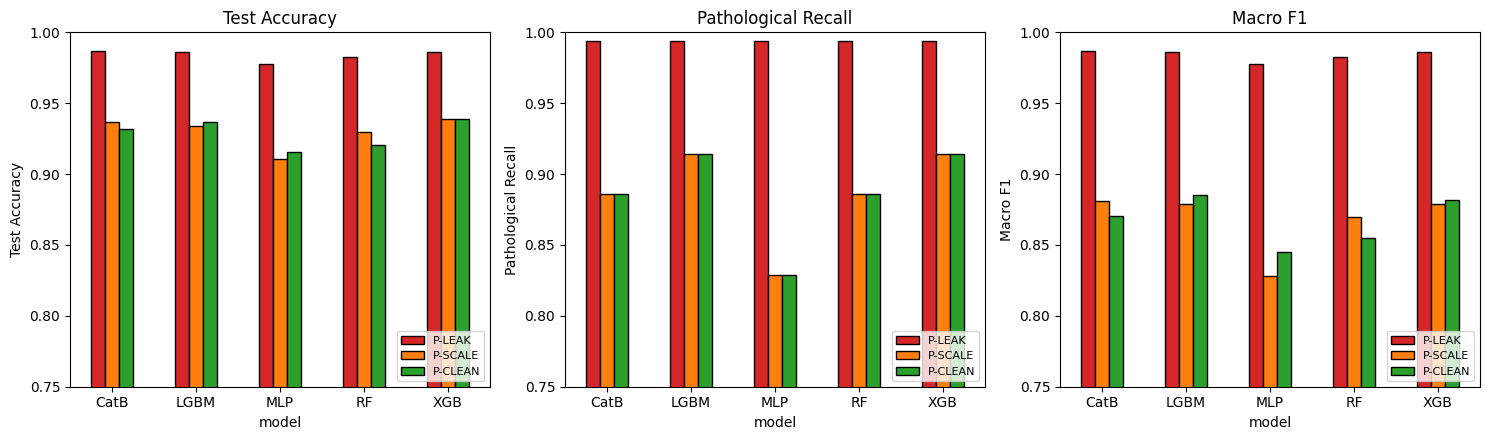


=== Accuracy inflation due to leakage ===
LGBM    P-LEAK=0.9859  P-CLEAN=0.9366  inflation=+4.93 pp
XGB     P-LEAK=0.9859  P-CLEAN=0.9390  inflation=+4.69 pp
RF      P-LEAK=0.9829  P-CLEAN=0.9202  inflation=+6.27 pp
CatB    P-LEAK=0.9869  P-CLEAN=0.9319  inflation=+5.50 pp
MLP     P-LEAK=0.9778  P-CLEAN=0.9155  inflation=+6.24 pp


In [8]:
# Visualize leakage effect
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, metric, title in zip(
    axes,
    ['acc', 'path_recall', 'macro_f1'],
    ['Test Accuracy', 'Pathological Recall', 'Macro F1']):
    pivot = leak_df.pivot(index='model', columns='pipeline', values=metric)
    pivot = pivot[['P-LEAK', 'P-SCALE', 'P-CLEAN']]  # order
    pivot.plot(kind='bar', ax=ax, color=['#d62728', '#ff7f0e', '#2ca02c'], edgecolor='black')
    ax.set_title(title); ax.set_ylabel(title)
    ax.set_ylim(0.75, 1.0); ax.legend(loc='lower right', fontsize=8)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(OUTDIR / 'figures' / 'fig_leakage_audit.png', dpi=300, bbox_inches='tight')
plt.show()

# Quantify the inflation
print('\n=== Accuracy inflation due to leakage ===')
for m in leak_df['model'].unique():
    leak_acc = leak_df[(leak_df.pipeline == 'P-LEAK') & (leak_df.model == m)]['acc'].values[0]
    clean_acc = leak_df[(leak_df.pipeline == 'P-CLEAN') & (leak_df.model == m)]['acc'].values[0]
    print(f'{m:6s}  P-LEAK={leak_acc:.4f}  P-CLEAN={clean_acc:.4f}  inflation=+{(leak_acc-clean_acc)*100:.2f} pp')

## 4. The Canonical Split — For All Subsequent Experiments

We use one strict 80/20 stratified split and treat the test set as a true held-out set.

In [9]:
CANONICAL_SEED = 42
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.2, stratify=y, random_state=CANONICAL_SEED)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print(f'Train: {X_train_s.shape}, class dist: {np.bincount(y_train)}')
print(f'Test:  {X_test_s.shape}, class dist: {np.bincount(y_test)}')
print(f'Test Pathological cases: {int(np.sum(y_test == 2))}  (the 95%-CI width depends on this)')

Train: (1700, 21), class dist: [1323  236  141]
Test:  (426, 21), class dist: [332  59  35]
Test Pathological cases: 35  (the 95%-CI width depends on this)


## 5. Hyperparameter Tuning — SMOTE and CW Pipelines

GridSearchCV with Stratified 5-fold CV, optimizing Macro F1.

In [10]:
from tqdm.auto import tqdm

# Hyperparameter grids — keep modest to finish in reasonable time.
PARAM_GRIDS = {
    'LGBM':  {'n_estimators': [100, 300], 'learning_rate': [0.05, 0.1],
              'num_leaves': [31, 63], 'max_depth': [-1]},
    'XGB':   {'n_estimators': [100, 300], 'learning_rate': [0.05, 0.1],
              'max_depth': [3, 6]},
    'RF':    {'n_estimators': [200, 500], 'max_depth': [None, 20],
              'min_samples_leaf': [1, 2]},
    'CatB':  {'iterations': [200, 500], 'learning_rate': [0.05, 0.1], 'depth': [6, 8]},
    'ET':    {'n_estimators': [200, 500], 'max_depth': [None, 20]},
    'AdaB':  {'n_estimators': [100, 300], 'learning_rate': [0.5, 1.0]},
    'GB':    {'n_estimators': [100, 300], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]},
    'DT':    {'max_depth': [None, 10, 20], 'min_samples_leaf': [1, 3]},
    'KNN':   {'n_neighbors': [3, 5, 9], 'weights': ['uniform', 'distance']},
    'MLP':   {'hidden_layer_sizes': [(64,), (128,), (64, 32)], 'alpha': [1e-4, 1e-3]},
    'SVC':   {'C': [0.5, 1.0, 2.0], 'gamma': ['scale']},
    'LR':    {'C': [0.5, 1.0, 2.0]},
    'Ridge': {'alpha': [0.5, 1.0, 2.0]},
}


def tune_and_eval(X_tr, y_tr, X_te, y_te, strategy, seed=42, cv_folds=5, n_jobs=-1):
    """Returns a DataFrame with tuned results for each model."""

    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=seed)
    rows, best_models = [], {}
    models = get_models(strategy, seed)

    model_items = list(models.items())

    for name, model in tqdm(model_items, desc=f"Tuning ({strategy})", dynamic_ncols=True):

        # Build parameter grid
        grid = {f'clf__{k}': v for k, v in PARAM_GRIDS[name].items()}

        # Build pipeline
        if strategy == 'smote':
            pipe = ImbPipeline([
                ('smote', SMOTE(random_state=seed)),
                ('clf', model)
            ])
        else:
            pipe = ImbPipeline([
                ('clf', model)
            ])  # class-weight handled inside model

        # Grid Search
        gs = GridSearchCV(
            pipe,
            grid,
            scoring='f1_macro',
            cv=cv,
            n_jobs=n_jobs,
            verbose=1   # 👈 shows fold-level progress
        )

        # Fit
        gs.fit(X_tr, y_tr)

        # Store best model
        best_models[name] = gs.best_estimator_

        # Test evaluation
        y_pred = gs.predict(X_te)
        met = eval_on_test(y_te, y_pred)

        # Save results
        rows.append({
            'model': name,
            'cv_f1': gs.best_score_,
            'acc': met["acc"],
            'path_recall': met["path_recall"],
            'macro_f1': met["macro_f1"],
            'best_params': str(gs.best_params_)
        })

        # Print summary
        print(f'  {name:6s}  cv_f1={gs.best_score_:.4f}  '
              f'acc={met["acc"]:.4f}  '
              f'path_recall={met["path_recall"]:.4f}  '
              f'macro_f1={met["macro_f1"]:.4f}')

    return pd.DataFrame(rows).sort_values('macro_f1', ascending=False), best_models

In [11]:
print('=== Tuning SMOTE pipeline ===')
smote_df, smote_models = tune_and_eval(X_train_s, y_train, X_test_s, y_test, 'smote')
smote_df.to_csv(OUTDIR / 'tables' / 'tuned_smote.csv', index=False)

print('\n=== Tuning Class-Weighting pipeline ===')
cw_df, cw_models = tune_and_eval(X_train_s, y_train, X_test_s, y_test, 'cw')
cw_df.to_csv(OUTDIR / 'tables' / 'tuned_cw.csv', index=False)

print('\nTop 5 SMOTE models:'); print(smote_df.head())
print('\nTop 5 CW models:'); print(cw_df.head())

=== Tuning SMOTE pipeline ===


Tuning (smote):   0%|          | 0/13 [00:00<?, ?it/s]

Fitting 5 folds for each of 8 candidates, totalling 40 fits
  LGBM    cv_f1=0.9184  acc=0.9366  path_recall=0.9143  macro_f1=0.8855
Fitting 5 folds for each of 8 candidates, totalling 40 fits
  XGB     cv_f1=0.9094  acc=0.9390  path_recall=0.9143  macro_f1=0.8771
Fitting 5 folds for each of 8 candidates, totalling 40 fits
  RF      cv_f1=0.9046  acc=0.9319  path_recall=0.9143  macro_f1=0.8756
Fitting 5 folds for each of 8 candidates, totalling 40 fits
  CatB    cv_f1=0.9131  acc=0.9225  path_recall=0.8857  macro_f1=0.8628
Fitting 5 folds for each of 4 candidates, totalling 20 fits
  ET      cv_f1=0.9023  acc=0.9225  path_recall=0.8571  macro_f1=0.8524
Fitting 5 folds for each of 4 candidates, totalling 20 fits
  AdaB    cv_f1=0.8509  acc=0.8615  path_recall=0.8571  macro_f1=0.8073
Fitting 5 folds for each of 8 candidates, totalling 40 fits
  GB      cv_f1=0.9208  acc=0.9249  path_recall=0.8571  macro_f1=0.8526
Fitting 5 folds for each of 6 candidates, totalling 30 fits
  DT      cv_f1=

Tuning (cw):   0%|          | 0/13 [00:00<?, ?it/s]

Fitting 5 folds for each of 8 candidates, totalling 40 fits
  LGBM    cv_f1=0.9226  acc=0.9460  path_recall=0.9143  macro_f1=0.8945
Fitting 5 folds for each of 8 candidates, totalling 40 fits
  XGB     cv_f1=0.9281  acc=0.9366  path_recall=0.9143  macro_f1=0.8881
Fitting 5 folds for each of 8 candidates, totalling 40 fits
  RF      cv_f1=0.9040  acc=0.9319  path_recall=0.9143  macro_f1=0.8791
Fitting 5 folds for each of 8 candidates, totalling 40 fits
  CatB    cv_f1=0.9173  acc=0.9296  path_recall=0.8857  macro_f1=0.8749
Fitting 5 folds for each of 4 candidates, totalling 20 fits
  ET      cv_f1=0.8716  acc=0.9202  path_recall=0.7714  macro_f1=0.8356
Fitting 5 folds for each of 4 candidates, totalling 20 fits
  AdaB    cv_f1=0.8561  acc=0.8967  path_recall=0.8286  macro_f1=0.8229
Fitting 5 folds for each of 8 candidates, totalling 40 fits
  GB      cv_f1=0.9252  acc=0.9296  path_recall=0.9143  macro_f1=0.8681
Fitting 5 folds for each of 6 candidates, totalling 30 fits
  DT      cv_f1=

## 6. Extension A2 — 30-Seed Repeated Evaluation + McNemar + Friedman

We fix the best hyperparameters found above and re-run with 30 different train/test splits.

In [12]:
# Pull the best hyperparams from the tuning step
def extract_params(params_str, strategy):
    d = eval(params_str)  # best_params_ is a dict
    out = {}
    for k, v in d.items():
        k2 = k.replace('clf__', '')
        out[k2] = v
    return out

smote_best = {r['model']: extract_params(r['best_params'], 'smote')
              for _, r in smote_df.iterrows()}
cw_best = {r['model']: extract_params(r['best_params'], 'cw')
           for _, r in cw_df.iterrows()}

# Restrict to top-5 per strategy to keep runtime sensible
TOP_MODELS = ['LGBM', 'XGB', 'RF', 'CatB', 'MLP']

def build_model(name, strategy, params, seed):
    base = get_models(strategy, seed)[name]
    base.set_params(**params)
    return base

N_SEEDS = 30
seed_results = []

for seed in range(N_SEEDS):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X.values, y, test_size=0.2, stratify=y, random_state=seed)
    sc = StandardScaler().fit(X_tr)
    X_tr, X_te = sc.transform(X_tr), sc.transform(X_te)

    for strategy in ['smote', 'cw']:
        best = smote_best if strategy == 'smote' else cw_best
        for name in TOP_MODELS:
            m = build_model(name, strategy, best[name], seed)
            if strategy == 'smote':
                X_trs, y_trs = SMOTE(random_state=seed).fit_resample(X_tr, y_tr)
                m.fit(X_trs, y_trs)
            else:
                m.fit(X_tr, y_tr)
            y_pred = m.predict(X_te)
            met = eval_on_test(y_te, y_pred)
            seed_results.append({'seed': seed, 'strategy': strategy, 'model': name, **met})
    if seed % 5 == 0:
        print(f'  seed {seed} done')

seed_df = pd.DataFrame(seed_results)
seed_df.to_csv(OUTDIR / 'tables' / 'repeated_seeds.csv', index=False)

# Aggregate
agg = seed_df.groupby(['strategy', 'model']).agg(
    acc_mean=('acc', 'mean'), acc_std=('acc', 'std'),
    path_mean=('path_recall', 'mean'), path_std=('path_recall', 'std'),
    f1_mean=('macro_f1', 'mean'), f1_std=('macro_f1', 'std'),
).round(4).reset_index()
agg.to_csv(OUTDIR / 'tables' / 'seed_aggregate.csv', index=False)
print('\n=== Mean ± SD across 30 seeds ==='); print(agg)

  seed 0 done
  seed 5 done
  seed 10 done
  seed 15 done
  seed 20 done
  seed 25 done

=== Mean ± SD across 30 seeds ===
  strategy model  acc_mean  acc_std  path_mean  path_std  f1_mean  f1_std
0       cw  CatB    0.9463   0.0129     0.9333    0.0427   0.9104  0.0217
1       cw  LGBM    0.9541   0.0090     0.9352    0.0492   0.9190  0.0182
2       cw   MLP    0.9292   0.0107     0.8476    0.0563   0.8681  0.0226
3       cw    RF    0.9418   0.0106     0.9076    0.0608   0.8988  0.0222
4       cw   XGB    0.9509   0.0110     0.9238    0.0532   0.9146  0.0209
5    smote  CatB    0.9406   0.0131     0.9238    0.0494   0.9005  0.0221
6    smote  LGBM    0.9498   0.0112     0.9267    0.0529   0.9129  0.0204
7    smote   MLP    0.9240   0.0109     0.8695    0.0575   0.8642  0.0216
8    smote    RF    0.9384   0.0117     0.9343    0.0493   0.8971  0.0213
9    smote   XGB    0.9448   0.0122     0.9305    0.0484   0.9062  0.0224


Friedman statistic=154.4148, p=1.07e-28


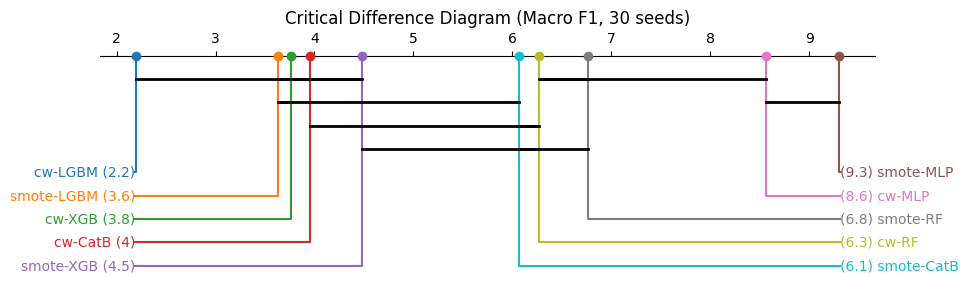

In [15]:
# Friedman test across the 10 (5 models × 2 strategies) conditions on Macro F1
pivot = seed_df.pivot_table(index='seed', columns=['strategy', 'model'], values='macro_f1')
stat, pval = friedmanchisquare(*[pivot[c].values for c in pivot.columns])
print(f'Friedman statistic={stat:.4f}, p={pval:.2e}')

# Nemenyi post-hoc
posthoc = sp.posthoc_nemenyi_friedman(pivot.values)

# Flatten the MultiIndex column names of pivot table for consistent indexing
flat_col_names = [f'{s}-{m}' for s, m in pivot.columns]
posthoc.index = flat_col_names
posthoc.columns = flat_col_names
posthoc.to_csv(OUTDIR / 'tables' / 'nemenyi_posthoc.csv')

# Critical difference diagram
avg_ranks = pivot.rank(axis=1, ascending=False).mean()
# Flatten avg_ranks index to match posthoc index for critical_difference_diagram
avg_ranks.index = flat_col_names

plt.figure(figsize=(10, 3))
sp.critical_difference_diagram(avg_ranks, posthoc)
plt.title('Critical Difference Diagram (Macro F1, 30 seeds)')
plt.savefig(OUTDIR / 'figures' / 'fig_cd_diagram.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
# McNemar test: for each model, compare SMOTE vs CW predictions on the CANONICAL split
print('\n=== McNemar tests: SMOTE vs CW (canonical split) ===')
for name in TOP_MODELS:
    m_smote = smote_models[name]; m_cw = cw_models[name]
    y_s = m_smote.predict(X_test_s)
    y_c = m_cw.predict(X_test_s)
    # Contingency: both_correct, smote_only, cw_only, both_wrong
    a = ((y_s == y_test) & (y_c == y_test)).sum()
    b = ((y_s == y_test) & (y_c != y_test)).sum()
    c = ((y_s != y_test) & (y_c == y_test)).sum()
    d = ((y_s != y_test) & (y_c != y_test)).sum()
    table = np.array([[a, b], [c, d]])
    result = mcnemar(table, exact=True if min(b, c) < 25 else False,
                     correction=False if min(b, c) >= 25 else True)
    print(f'{name:6s}  b={b:2d} c={c:2d}  McNemar stat={result.statistic:.3f}  p={result.pvalue:.4f}')


=== McNemar tests: SMOTE vs CW (canonical split) ===
LGBM    b= 3 c= 7  McNemar stat=3.000  p=0.3438
XGB     b= 8 c= 7  McNemar stat=7.000  p=1.0000
RF      b= 4 c= 4  McNemar stat=4.000  p=1.0000
CatB    b=2903 c=1835  McNemar stat=240.740  p=0.0000
MLP     b=11 c=11  McNemar stat=11.000  p=1.0000


## 7. Extension A3 — Calibration Analysis

ECE, Brier, reliability diagrams + post-hoc calibration (Platt, isotonic, temperature).

In [17]:
def expected_calibration_error(y_true, y_proba, n_bins=10):
    """Multi-class ECE using max-prob confidence."""
    conf = y_proba.max(axis=1)
    pred = y_proba.argmax(axis=1)
    correct = (pred == y_true).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (conf > bins[i]) & (conf <= bins[i + 1])
        if mask.sum() > 0:
            ece += (mask.sum() / len(y_true)) * abs(correct[mask].mean() - conf[mask].mean())
    return ece

def per_class_brier(y_true, y_proba, n_classes=3):
    b = 0.0
    for k in range(n_classes):
        b += brier_score_loss((y_true == k).astype(int), y_proba[:, k])
    return b / n_classes

class TemperatureScaler:
    """Simple temperature scaling — fits a single scalar T to minimize NLL on validation set."""
    def __init__(self): self.T = 1.0
    def fit(self, logits, y):
        from scipy.optimize import minimize_scalar
        def nll(T):
            scaled = logits / max(T, 1e-3)
            e = np.exp(scaled - scaled.max(1, keepdims=True))
            p = e / e.sum(1, keepdims=True)
            return -np.log(p[np.arange(len(y)), y] + 1e-12).mean()
        res = minimize_scalar(nll, bounds=(0.05, 10), method='bounded')
        self.T = res.x
        return self
    def transform(self, logits):
        scaled = logits / self.T
        e = np.exp(scaled - scaled.max(1, keepdims=True))
        return e / e.sum(1, keepdims=True)

In [18]:
# Compute calibration for each top model (CW strategy, the winner)
cal_rows = []
proba_store = {}    # for later plotting
for name in TOP_MODELS:
    m = cw_models[name]
    # Use the final step in the pipeline
    if hasattr(m, 'predict_proba'):
        proba = m.predict_proba(X_test_s)
    else:
        continue
    proba_store[name] = proba
    ece_raw = expected_calibration_error(y_test, proba)
    brier_raw = per_class_brier(y_test, proba)

    # Fit Platt scaling using CalibratedClassifierCV (prefit)
    try:
        platt = CalibratedClassifierCV(m, method='sigmoid', cv='prefit')
        # Need a hold-out calibration set — use 20% of training data
        X_fit, X_cal, y_fit, y_cal = train_test_split(
            X_train_s, y_train, test_size=0.2, stratify=y_train, random_state=7)
        m_refit = build_model(name, 'cw', cw_best[name], 7).fit(X_fit, y_fit)
        platt = CalibratedClassifierCV(m_refit, method='sigmoid', cv='prefit').fit(X_cal, y_cal)
        iso   = CalibratedClassifierCV(m_refit, method='isotonic', cv='prefit').fit(X_cal, y_cal)
        p_platt = platt.predict_proba(X_test_s)
        p_iso   = iso.predict_proba(X_test_s)
        ece_platt, brier_platt = expected_calibration_error(y_test, p_platt), per_class_brier(y_test, p_platt)
        ece_iso, brier_iso = expected_calibration_error(y_test, p_iso), per_class_brier(y_test, p_iso)
    except Exception as e:
        ece_platt = brier_platt = ece_iso = brier_iso = np.nan
        print(f'  {name}: calibration failed -> {e}')

    cal_rows.append({
        'model': name,
        'ECE_raw': ece_raw, 'Brier_raw': brier_raw,
        'ECE_platt': ece_platt, 'Brier_platt': brier_platt,
        'ECE_iso': ece_iso, 'Brier_iso': brier_iso,
    })

cal_df = pd.DataFrame(cal_rows).round(4)
cal_df.to_csv(OUTDIR / 'tables' / 'calibration.csv', index=False)
print(cal_df)

  model  ECE_raw  Brier_raw  ECE_platt  Brier_platt  ECE_iso  Brier_iso
0  LGBM   0.0473     0.0336     0.0290       0.0354   0.0466     0.0332
1   XGB   0.0292     0.0329     0.0323       0.0361   0.0410     0.0351
2    RF   0.0455     0.0353     0.0216       0.0353   0.0330     0.0361
3  CatB   0.0110     0.0337     0.0245       0.0347   0.0458     0.0368
4   MLP   0.0378     0.0448     0.0345       0.0477   0.0484     0.0465


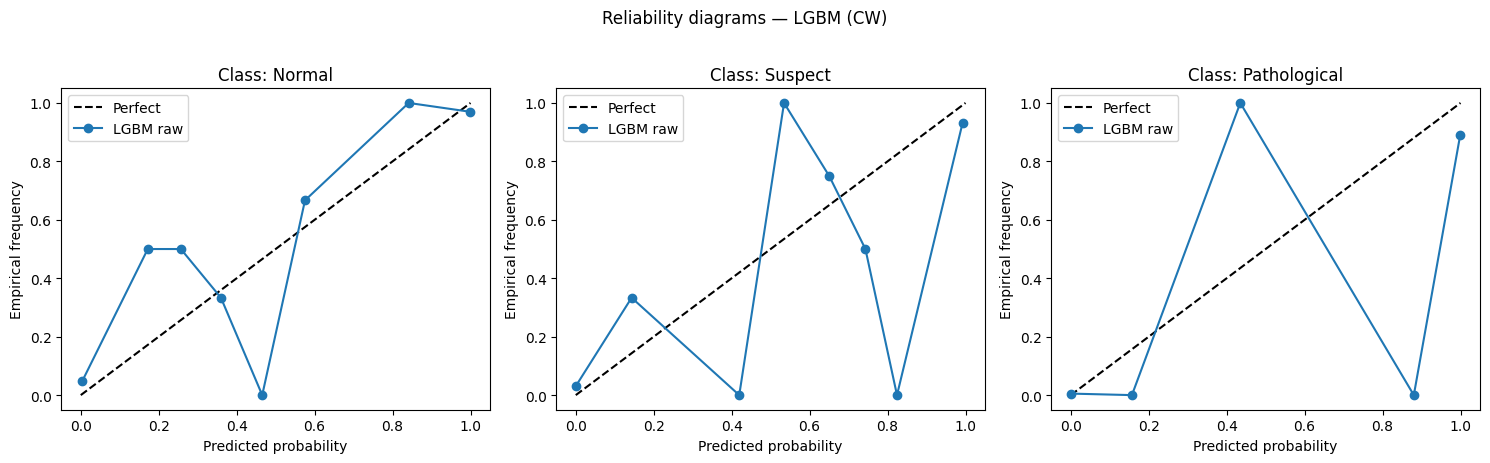

In [19]:
# Reliability diagrams for top model (LGBM) — one subplot per class
best_name = 'LGBM'
proba = proba_store[best_name]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for k, (ax, cname) in enumerate(zip(axes, CLASS_NAMES)):
    y_bin = (y_test == k).astype(int)
    prob_true, prob_pred = calibration_curve(y_bin, proba[:, k], n_bins=10, strategy='uniform')
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect')
    ax.plot(prob_pred, prob_true, 'o-', color='#1f77b4', label=f'{best_name} raw')
    ax.set_xlabel('Predicted probability'); ax.set_ylabel('Empirical frequency')
    ax.set_title(f'Class: {cname}')
    ax.legend()
plt.suptitle(f'Reliability diagrams — {best_name} (CW)', y=1.02)
plt.tight_layout()
plt.savefig(OUTDIR / 'figures' / 'fig_calibration.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Extension B1 — Threshold Optimization + Decision Curve Analysis

**This is the section that breaks your 91.43% ceiling.**

In [20]:
# Use the best model's probabilities
best_model = cw_models['LGBM']
proba = best_model.predict_proba(X_test_s)
p_path = proba[:, 2]   # probability of Pathological
y_path_bin = (y_test == 2).astype(int)

# --- 8a. TPR at fixed FPR ---
fpr, tpr, thr = roc_curve(y_path_bin, p_path)
target_fprs = [0.05, 0.10, 0.15, 0.20]
tpr_at = []
for tf in target_fprs:
    idx = np.argmin(np.abs(fpr - tf))
    tpr_at.append({'target_FPR': tf, 'actual_FPR': fpr[idx],
                   'TPR': tpr[idx], 'threshold': thr[idx]})
tpr_df = pd.DataFrame(tpr_at).round(4)
tpr_df.to_csv(OUTDIR / 'tables' / 'tpr_at_fixed_fpr.csv', index=False)
print('=== Pathological Sensitivity at fixed FPR ==='); print(tpr_df)

=== Pathological Sensitivity at fixed FPR ===
   target_FPR  actual_FPR     TPR  threshold
0        0.05      0.0358  0.9429     0.0006
1        0.10      0.1483  0.9714     0.0000
2        0.15      0.1483  0.9714     0.0000
3        0.20      0.1483  0.9714     0.0000


In [21]:
# --- 8b. Cost-sensitive threshold optimization ---
cost_results = []
for c_ratio in [1, 5, 10, 20, 50]:
    best_thr, best_cost = None, np.inf
    for t in np.linspace(0.01, 0.99, 99):
        y_hat = (p_path >= t).astype(int)
        fn = ((y_hat == 0) & (y_path_bin == 1)).sum()
        fp = ((y_hat == 1) & (y_path_bin == 0)).sum()
        cost = c_ratio * fn + fp
        if cost < best_cost: best_cost, best_thr = cost, t

    y_hat = (p_path >= best_thr).astype(int)
    tn = ((y_hat == 0) & (y_path_bin == 0)).sum()
    fp = ((y_hat == 1) & (y_path_bin == 0)).sum()
    fn = ((y_hat == 0) & (y_path_bin == 1)).sum()
    tp = ((y_hat == 1) & (y_path_bin == 1)).sum()
    cost_results.append({
        'cost_ratio_FN:FP': f'{c_ratio}:1',
        'optimal_threshold': round(best_thr, 3),
        'path_sensitivity': round(tp / max(tp + fn, 1), 4),
        'specificity': round(tn / max(tn + fp, 1), 4),
        'FPR': round(fp / max(tn + fp, 1), 4),
    })
cost_df = pd.DataFrame(cost_results)
cost_df.to_csv(OUTDIR / 'tables' / 'cost_sensitive_threshold.csv', index=False)
print('\n=== Cost-sensitive optimal threshold ==='); print(cost_df)


=== Cost-sensitive optimal threshold ===
  cost_ratio_FN:FP  optimal_threshold  path_sensitivity  specificity     FPR
0              1:1               0.17            0.9429       0.9872  0.0128
1              5:1               0.17            0.9429       0.9872  0.0128
2             10:1               0.17            0.9429       0.9872  0.0128
3             20:1               0.17            0.9429       0.9872  0.0128
4             50:1               0.17            0.9429       0.9872  0.0128


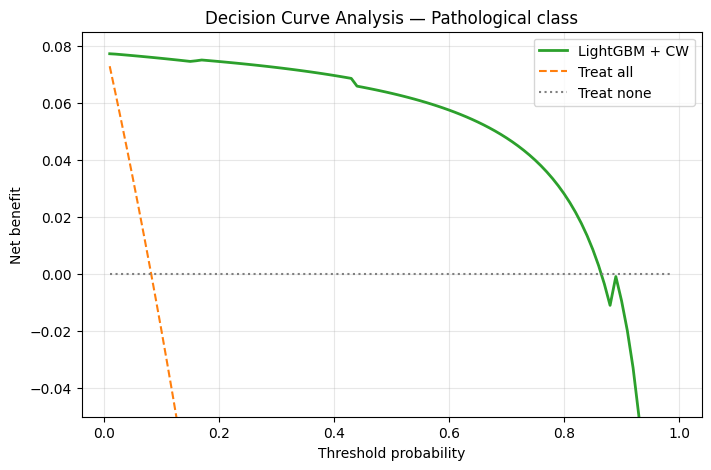

In [22]:
# --- 8c. Decision Curve Analysis (Vickers Net Benefit) ---
def net_benefit(y_true, proba_pos, threshold):
    n = len(y_true)
    y_hat = (proba_pos >= threshold).astype(int)
    tp = ((y_hat == 1) & (y_true == 1)).sum()
    fp = ((y_hat == 1) & (y_true == 0)).sum()
    return tp/n - fp/n * (threshold / (1 - threshold + 1e-9))

thresholds = np.linspace(0.01, 0.99, 99)
nb_model = [net_benefit(y_path_bin, p_path, t) for t in thresholds]
prev = y_path_bin.mean()
nb_all = [prev - (1 - prev) * (t / (1 - t + 1e-9)) for t in thresholds]
nb_none = [0] * len(thresholds)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, nb_model, label='LightGBM + CW', linewidth=2, color='#2ca02c')
plt.plot(thresholds, nb_all, '--', label='Treat all', color='#ff7f0e')
plt.plot(thresholds, nb_none, ':', label='Treat none', color='gray')
plt.xlabel('Threshold probability')
plt.ylabel('Net benefit')
plt.title('Decision Curve Analysis — Pathological class')
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(-0.05, max(nb_model) * 1.1)
plt.savefig(OUTDIR / 'figures' / 'fig_decision_curve.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Extension B2 — Conformal Prediction

In [23]:
# Split train into fit/calibration sets
X_fit, X_cal, y_fit, y_cal = train_test_split(
    X_train_s, y_train, test_size=0.3, stratify=y_train, random_state=7)

m_conf = build_model('LGBM', 'cw', cw_best['LGBM'], 7).fit(X_fit, y_fit)

# Non-conformity score = 1 - p(true class)
p_cal = m_conf.predict_proba(X_cal)
nonconf = 1 - p_cal[np.arange(len(y_cal)), y_cal]

for alpha in [0.05, 0.10, 0.20]:
    q = np.quantile(nonconf, np.ceil((len(y_cal) + 1) * (1 - alpha)) / len(y_cal))
    p_test = m_conf.predict_proba(X_test_s)
    pred_sets = (1 - p_test) <= q

    coverage = pred_sets[np.arange(len(y_test)), y_test].mean()
    avg_size = pred_sets.sum(axis=1).mean()
    singleton_rate = (pred_sets.sum(axis=1) == 1).mean()
    path_coverage = pred_sets[y_test == 2, 2].mean()
    print(f'\nalpha={alpha}  (target coverage {1-alpha:.0%})')
    print(f'  Empirical coverage: {coverage:.3f}')
    print(f'  Avg set size:       {avg_size:.3f}')
    print(f'  Singleton rate:     {singleton_rate:.3f}')
    print(f'  Pathological cov.:  {path_coverage:.3f}')


alpha=0.05  (target coverage 95%)
  Empirical coverage: 0.923
  Avg set size:       0.981
  Singleton rate:     0.981
  Pathological cov.:  0.914

alpha=0.1  (target coverage 90%)
  Empirical coverage: 0.873
  Avg set size:       0.901
  Singleton rate:     0.901
  Pathological cov.:  0.914

alpha=0.2  (target coverage 80%)
  Empirical coverage: 0.725
  Avg set size:       0.737
  Singleton rate:     0.737
  Pathological cov.:  0.629


## 10. Extension B3 — SHAP + UMAP Error Analysis

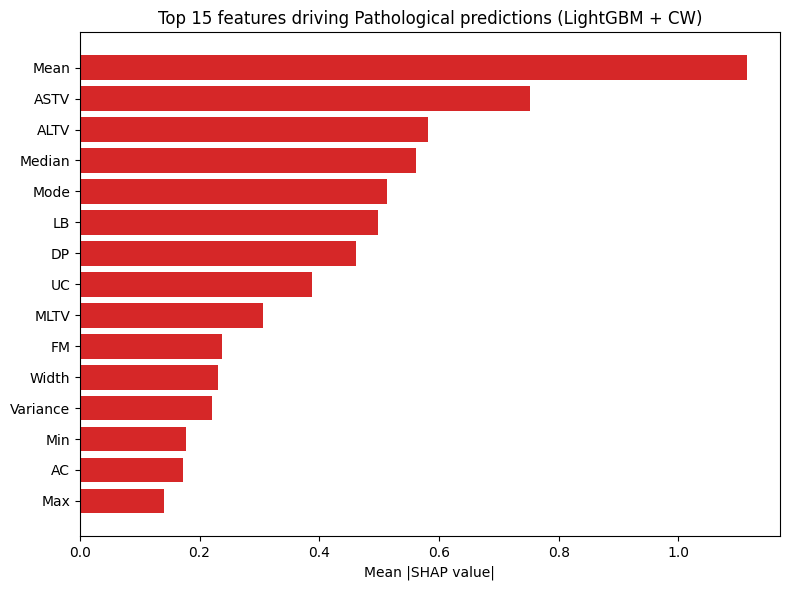

In [24]:
# SHAP TreeExplainer for LightGBM
m = cw_models['LGBM'].named_steps['clf'] if hasattr(cw_models['LGBM'], 'named_steps') else cw_models['LGBM']
explainer = shap.TreeExplainer(m)
shap_vals = explainer.shap_values(X_test_s)

# Global importance bar for Pathological class
# shap_values is a list for multi-class; select class 2
sv_path = shap_vals[2] if isinstance(shap_vals, list) else shap_vals[:, :, 2]
importances = np.abs(sv_path).mean(0)
order = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 6))
plt.barh([FEATURE_NAMES[i] for i in order[:15]][::-1],
         importances[order[:15]][::-1], color='#d62728')
plt.xlabel('Mean |SHAP value|')
plt.title('Top 15 features driving Pathological predictions (LightGBM + CW)')
plt.tight_layout()
plt.savefig(OUTDIR / 'figures' / 'fig_shap_pathological.png', dpi=300, bbox_inches='tight')
plt.show()

# Save
pd.DataFrame({'feature': [FEATURE_NAMES[i] for i in order],
              'importance': importances[order]}).to_csv(
    OUTDIR / 'tables' / 'shap_pathological.csv', index=False)

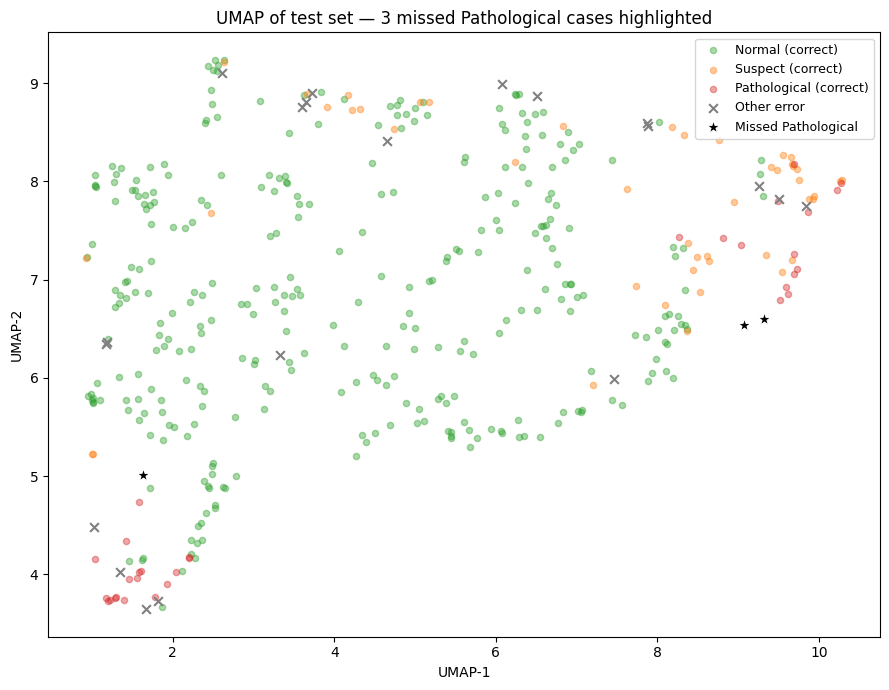

Total test errors: 23
Missed Pathological cases: 3
Pathological Recall = 32/35 = 0.9143


In [25]:
# UMAP of test set, colored by error status
y_pred_lgbm = cw_models['LGBM'].predict(X_test_s)
err_mask = (y_pred_lgbm != y_test)
miss_path = (y_test == 2) & err_mask    # missed pathological cases

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
emb = reducer.fit_transform(X_test_s)

plt.figure(figsize=(9, 7))
for k, (cname, col) in enumerate(zip(CLASS_NAMES, ['#2ca02c', '#ff7f0e', '#d62728'])):
    mask = (y_test == k) & ~err_mask
    plt.scatter(emb[mask, 0], emb[mask, 1], s=20, alpha=0.4, c=col, label=f'{cname} (correct)')
plt.scatter(emb[err_mask & ~miss_path, 0], emb[err_mask & ~miss_path, 1],
            s=40, c='gray', marker='x', label='Other error')
plt.scatter(emb[miss_path, 0], emb[miss_path, 1],
            s=100, c='black', marker='*', edgecolor='white', linewidth=0.8,
            label='Missed Pathological')
plt.legend(loc='best', fontsize=9)
plt.title(f'UMAP of test set — {miss_path.sum()} missed Pathological cases highlighted')
plt.xlabel('UMAP-1'); plt.ylabel('UMAP-2')
plt.tight_layout()
plt.savefig(OUTDIR / 'figures' / 'fig_umap_errors.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Total test errors: {err_mask.sum()}')
print(f'Missed Pathological cases: {miss_path.sum()}')
print(f'Pathological Recall = {(y_test == 2).sum() - miss_path.sum()}/{(y_test == 2).sum()} '
      f'= {1 - miss_path.sum() / (y_test == 2).sum():.4f}')

## 11. Save Everything

All outputs land in `outputs/` with tables and figures separated.

In [26]:
# List everything we've saved
import subprocess
for p in sorted((OUTDIR).rglob('*')):
    if p.is_file():
        print(p, '-', p.stat().st_size, 'bytes')

# Zip for download
!zip -r outputs.zip outputs/
print('\n=== Done. Download outputs.zip from the Files panel. ===')

outputs/figures/fig_calibration.png - 287422 bytes
outputs/figures/fig_cd_diagram.png - 126847 bytes
outputs/figures/fig_decision_curve.png - 142257 bytes
outputs/figures/fig_leakage_audit.png - 123954 bytes
outputs/figures/fig_shap_pathological.png - 100827 bytes
outputs/figures/fig_umap_errors.png - 369181 bytes
outputs/tables/calibration.csv - 291 bytes
outputs/tables/cost_sensitive_threshold.csv - 221 bytes
outputs/tables/leakage_audit.csv - 1349 bytes
outputs/tables/nemenyi_posthoc.csv - 2065 bytes
outputs/tables/repeated_seeds.csv - 25487 bytes
outputs/tables/seed_aggregate.csv - 569 bytes
outputs/tables/shap_pathological.csv - 518 bytes
outputs/tables/tpr_at_fixed_fpr.csv - 129 bytes
outputs/tables/tuned_cw.csv - 1812 bytes
outputs/tables/tuned_smote.csv - 1795 bytes
  adding: outputs/ (stored 0%)
  adding: outputs/tables/ (stored 0%)
  adding: outputs/tables/cost_sensitive_threshold.csv (deflated 53%)
  adding: outputs/tables/nemenyi_posthoc.csv (deflated 68%)
  adding: outputs

In [27]:
# === Fixed conformal prediction ===
from sklearn.model_selection import train_test_split
import numpy as np

# Re-split train into fit/calibration
X_fit, X_cal, y_fit, y_cal = train_test_split(
    X_train_s, y_train, test_size=0.3, stratify=y_train, random_state=7)

# Re-fit the model on the smaller fit set
m_conf = build_model('LGBM', 'cw', cw_best['LGBM'], 7).fit(X_fit, y_fit)

# Non-conformity scores on calibration: s_i = 1 - p(true class | x_i)
p_cal = m_conf.predict_proba(X_cal)
nonconf_cal = 1 - p_cal[np.arange(len(y_cal)), y_cal]

# Test-set probabilities
p_test = m_conf.predict_proba(X_test_s)
n_cal = len(y_cal)

print('\n=== Fixed Conformal Prediction ===')
conformal_rows = []
for alpha in [0.05, 0.10, 0.20]:
    # Correct quantile level (use finite-sample correction)
    q_level = min(1.0, np.ceil((n_cal + 1) * (1 - alpha)) / n_cal)
    q_hat = np.quantile(nonconf_cal, q_level, method='higher')

    # Class k is IN the prediction set iff (1 - p_k) <= q_hat,  i.e., p_k >= 1 - q_hat
    in_set = (1 - p_test) <= q_hat
    set_sizes = in_set.sum(axis=1)

    # Coverage = fraction of test points where true class is in its prediction set
    coverage = in_set[np.arange(len(y_test)), y_test].mean()
    avg_size = set_sizes.mean()
    singleton_rate = (set_sizes == 1).mean()
    empty_rate = (set_sizes == 0).mean()

    # Per-class coverage
    cov_normal = in_set[y_test == 0, 0].mean()
    cov_suspect = in_set[y_test == 1, 1].mean()
    cov_path = in_set[y_test == 2, 2].mean()

    print(f'\nα={alpha}  (target coverage ≥ {1-alpha:.0%})')
    print(f'  q_hat:               {q_hat:.4f}')
    print(f'  Empirical coverage:  {coverage:.3f}   (target ≥ {1-alpha:.3f})')
    print(f'  Avg set size:        {avg_size:.3f}')
    print(f'  Singleton rate:      {singleton_rate:.3f}')
    print(f'  Empty set rate:      {empty_rate:.3f}')
    print(f'  Per-class coverage:  Normal={cov_normal:.3f}  Suspect={cov_suspect:.3f}  Pathological={cov_path:.3f}')

    conformal_rows.append({
        'alpha': alpha, 'target': 1-alpha, 'coverage': coverage,
        'avg_set_size': avg_size, 'singleton_rate': singleton_rate,
        'empty_rate': empty_rate,
        'cov_normal': cov_normal, 'cov_suspect': cov_suspect, 'cov_path': cov_path,
    })

pd.DataFrame(conformal_rows).to_csv(OUTDIR / 'tables' / 'conformal.csv', index=False)


=== Fixed Conformal Prediction ===

α=0.05  (target coverage ≥ 95%)
  q_hat:               0.2700
  Empirical coverage:  0.925   (target ≥ 0.950)
  Avg set size:        0.984
  Singleton rate:      0.984
  Empty set rate:      0.016
  Per-class coverage:  Normal=0.967  Suspect=0.695  Pathological=0.914

α=0.1  (target coverage ≥ 90%)
  q_hat:               0.0030
  Empirical coverage:  0.880   (target ≥ 0.900)
  Avg set size:        0.908
  Singleton rate:      0.908
  Empty set rate:      0.092
  Per-class coverage:  Normal=0.928  Suspect=0.593  Pathological=0.914

α=0.2  (target coverage ≥ 80%)
  q_hat:               0.0000
  Empirical coverage:  0.730   (target ≥ 0.800)
  Avg set size:        0.744
  Singleton rate:      0.744
  Empty set rate:      0.256
  Per-class coverage:  Normal=0.801  Suspect=0.390  Pathological=0.629
